# M5 Probabilistic Forecasting — Evaluacion (Fase 6)

**Objetivo:** comparativa honesta entre ARIMA clasico, BQML ARIMA_PLUS y LightGBM Cuantil sobre walk-forward CV (5 folds, Fase 5), mas analisis narrativo de casos dificiles pedido en `INSTRUCCIONES.md`.

**Tablas consumidas (todas ya construidas en BigQuery, ver `src/evaluation/`):**
- `cv_pinball_loss`, `cv_metrics_by_fold_quantile`, `cv_metrics_by_category`, `cv_metrics_overall` — `build_cv_metrics.py`
- `cv_metrics_by_product_category`, `cv_metrics_by_release_age`, `cv_metrics_by_event` — `build_case_analysis.py`
- `arima_metadata_cv` — convergencia de ARIMA por fold (Fase 5)

**Nota de alcance:** la comparacion "justa" (3 modelos) esta limitada a las 32 series de `arima_sample` (`in_arima_sample=TRUE`) porque ARIMA clasico nunca corrio sobre `lgbm_sample` completo (ver `phase-summaries/04-modelos.md`). BQML vs. LightGBM sobre las ~3,000 series de `lgbm_sample` se reporta aparte.

**Proyecto:** mle-m5-forecast | **Dataset:** m5_dataset


In [10]:
# Setup
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT = 'mle-m5-forecast'
DATASET = 'm5_dataset'
client = bigquery.Client(project=PROJECT)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
MODEL_ORDER = ['arima', 'bqml', 'lgbm']
MODEL_LABELS = {'arima': 'ARIMA', 'bqml': 'BQML ARIMA_PLUS', 'lgbm': 'LightGBM Cuantil'}

def weighted_pivot(df, index_col, index_order=None):
    """Promedio ponderado por n_obs antes de pivotear (colapsa filas
    duplicadas de un mismo index_col con distinto valor de in_arima_sample)."""
    w = df.assign(weighted=df['avg_pinball_loss'] * df['n_obs'])
    agg = w.groupby([index_col, 'model'], as_index=False).agg(weighted_sum=('weighted', 'sum'), n_obs_sum=('n_obs', 'sum'))
    agg['avg_pinball_loss'] = agg['weighted_sum'] / agg['n_obs_sum']
    pivot = agg.pivot(index=index_col, columns='model', values='avg_pinball_loss')
    if index_order is not None:
        pivot = pivot.reindex([b for b in index_order if b in pivot.index])
    return pivot[[m for m in MODEL_ORDER if m in pivot.columns]]

def fair_and_full(df, index_col, index_order=None):
    """Split de dos alcances (mismo principio que Seccion 1): arima SOLO
    tiene predicciones para las 32 series de arima_sample -- comparar la
    fila 'arima' contra un bqml/lgbm promediado sobre lgbm_sample completo
    mezcla poblaciones distintas. Devuelve (pivot_justo_3_modelos,
    pivot_bqml_vs_lgbm_scope_completo)."""
    fair = weighted_pivot(df[df['in_arima_sample']], index_col, index_order)
    full = weighted_pivot(df[df['model'].isin(['bqml', 'lgbm'])], index_col, index_order)
    return fair, full

print(f'✓ Conectado a {PROJECT}.{DATASET}')

✓ Conectado a mle-m5-forecast.m5_dataset


## 1. Comparativa general de modelos (walk-forward CV, 5 folds)

Pinball Loss promedio por percentil. Resultado ya documentado en `phase-summaries/05-walk-forward-cv.md` y `README.md` — aca se reproduce con codigo ejecutable y se agrega el grafico.

In [11]:
query = f"""
SELECT model, quantile_name, quantile_level, in_arima_sample, n_obs, avg_pinball_loss
FROM `{PROJECT}.{DATASET}.cv_metrics_overall`
ORDER BY model, quantile_level
"""
df_overall = client.query(query).to_dataframe()

print('=== Comparacion justa -- 32 series de arima_sample, presentes en los 3 modelos ===')
fair = df_overall[df_overall['in_arima_sample']]
pivot_fair = fair.pivot(index='quantile_name', columns='model', values='avg_pinball_loss').reindex(
    ['p05', 'p25', 'p50', 'p75', 'p95'])[MODEL_ORDER]
display(pivot_fair)

print('\n=== BQML vs LightGBM -- scope completo (~3,000 series de lgbm_sample) ===')
df_overall['weighted'] = df_overall['avg_pinball_loss'] * df_overall['n_obs']
full_scope = df_overall.groupby(['model', 'quantile_name', 'quantile_level'], as_index=False).agg(
    weighted_sum=('weighted', 'sum'), n_obs_sum=('n_obs', 'sum'))
full_scope['avg_pinball_loss'] = full_scope['weighted_sum'] / full_scope['n_obs_sum']
pivot_full = full_scope[full_scope['model'].isin(['bqml', 'lgbm'])].pivot(
    index='quantile_name', columns='model', values='avg_pinball_loss').reindex(
    ['p05', 'p25', 'p50', 'p75', 'p95'])
display(pivot_full)

=== Comparacion justa -- 32 series de arima_sample, presentes en los 3 modelos ===


model,arima,bqml,lgbm
quantile_name,,,
p05,0.221484,0.226644,0.181720
p25,0.940442,0.797247,0.620569
p50,1.319289,1.149969,0.873862
p75,1.180174,1.064935,0.801163
p95,0.455548,0.496384,0.361126



=== BQML vs LightGBM -- scope completo (~3,000 series de lgbm_sample) ===


model,bqml,lgbm
quantile_name,,
p05,0.092924,0.05845
p25,0.30605,0.240418
p50,0.458562,0.379079
p75,0.454602,0.37583
p95,0.274261,0.16853


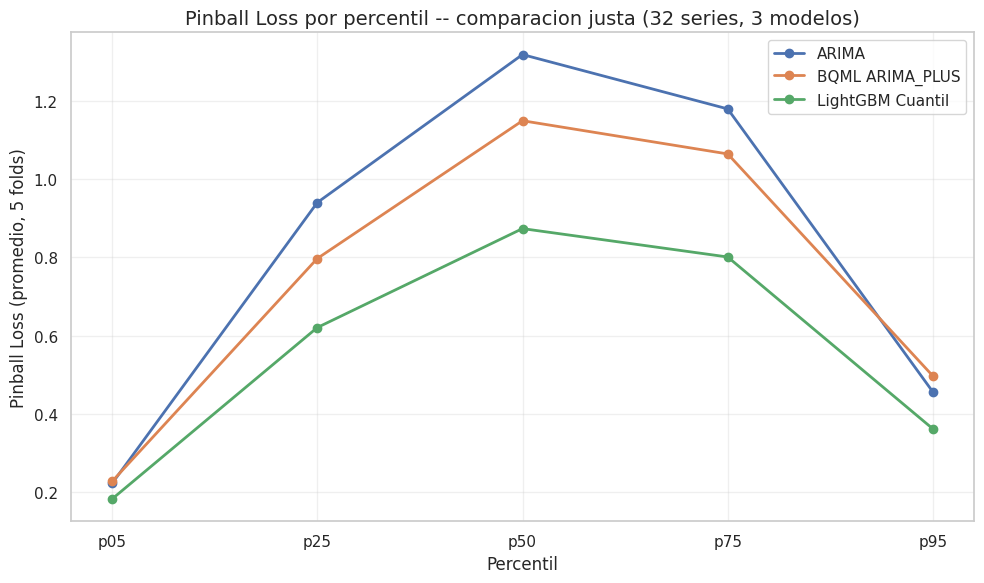

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
for model in MODEL_ORDER:
    sub = pivot_fair[model]
    ax.plot(sub.index, sub.values, marker='o', label=MODEL_LABELS[model], linewidth=2)
ax.set_title('Pinball Loss por percentil -- comparacion justa (32 series, 3 modelos)', fontsize=14)
ax.set_xlabel('Percentil')
ax.set_ylabel('Pinball Loss (promedio, 5 folds)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Pinball Loss por categoria real (FOODS / HOBBIES / HOUSEHOLD)

Fuente: `cv_metrics_by_product_category` (`src/evaluation/build_case_analysis.py`). Un modelo puede ser bueno en P50 global y malo en una categoria especifica -- ver `skill-m5-evaluation.md`.

In [13]:
query = f"""
SELECT model, quantile_name, quantile_level, category, in_arima_sample, n_obs, avg_pinball_loss
FROM `{PROJECT}.{DATASET}.cv_metrics_by_product_category`
ORDER BY category, model, quantile_level
"""
df_cat = client.query(query).to_dataframe()

cat_order = ['FOODS', 'HOBBIES', 'HOUSEHOLD']
p50_cat = df_cat[df_cat['quantile_name'] == 'p50']
pivot_cat_fair, pivot_cat_full = fair_and_full(p50_cat, 'category', cat_order)

print('=== Comparacion justa (32 series arima_sample, 3 modelos) ===')
display(pivot_cat_fair)
print('\n=== BQML vs LightGBM, scope completo (~3,000 series lgbm_sample) ===')
display(pivot_cat_full)

=== Comparacion justa (32 series arima_sample, 3 modelos) ===


model,arima,bqml,lgbm
category,,,
FOODS,1.994389,1.795689,1.337313
HOBBIES,0.16666,0.114176,0.097341
HOUSEHOLD,0.673769,0.594265,0.482658



=== BQML vs LightGBM, scope completo (~3,000 series lgbm_sample) ===


model,bqml,lgbm
category,,
FOODS,0.64047,0.517018
HOBBIES,0.305535,0.269775
HOUSEHOLD,0.296959,0.252893


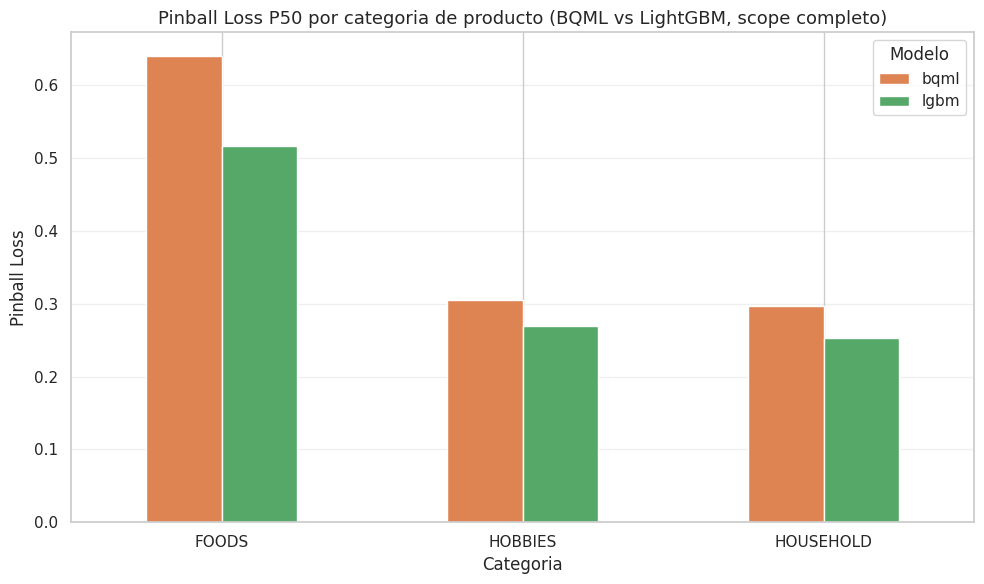

In [14]:
pivot_cat_full.plot(kind='bar', figsize=(10, 6), color=['#DD8452', '#55A868'])
plt.title('Pinball Loss P50 por categoria de producto (BQML vs LightGBM, scope completo)', fontsize=13)
plt.ylabel('Pinball Loss')
plt.xlabel('Categoria')
plt.xticks(rotation=0)
plt.legend(title='Modelo')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Casos dificiles

Tres segmentos pedidos en `INSTRUCCIONES.md` / `skill-m5-evaluation.md`: series con alta tasa de ceros, productos nuevos sin historia, semanas con eventos especiales.

### 3.1 Series con alta tasa de ceros

Fuente: `cv_metrics_by_category` (`categoria_zero_rate`, Fase 5). Buckets: `rapido` (<20% ceros), `medio` (20-50%), `lento` (50-80%), `muy_lento` (>=80%).

=== Comparacion justa (32 series arima_sample, 3 modelos) ===


model,arima,bqml,lgbm
categoria_zero_rate,,,
rapido,3.118454,3.267045,2.350987
medio,0.977772,0.979313,0.820641
lento,0.334039,0.266426,0.241856
muy_lento,0.153714,0.087091,0.081965



=== BQML vs LightGBM, scope completo (~3,000 series lgbm_sample) ===


model,bqml,lgbm
categoria_zero_rate,,
rapido,2.00415,1.632893
medio,1.02243,0.838577
lento,0.399812,0.333605
muy_lento,0.114663,0.097012


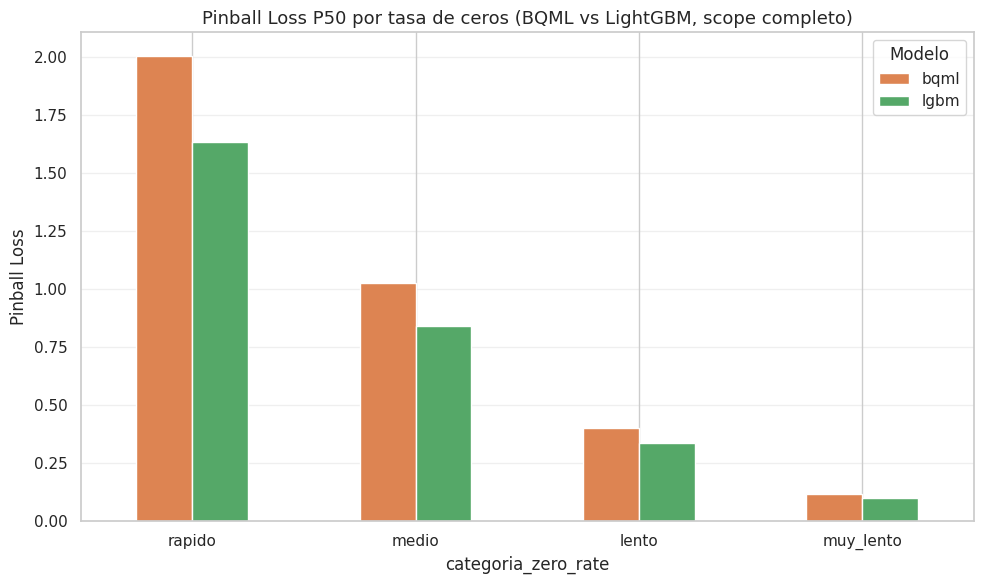

In [15]:
query = f"""
SELECT model, quantile_name, quantile_level, categoria_zero_rate, in_arima_sample, n_obs, avg_pinball_loss
FROM `{PROJECT}.{DATASET}.cv_metrics_by_category`
WHERE quantile_name = 'p50'
ORDER BY categoria_zero_rate, model
"""
df_zero = client.query(query).to_dataframe()
zero_order = ['rapido', 'medio', 'lento', 'muy_lento']
pivot_zero_fair, pivot_zero_full = fair_and_full(df_zero, 'categoria_zero_rate', zero_order)

print('=== Comparacion justa (32 series arima_sample, 3 modelos) ===')
display(pivot_zero_fair)
print('\n=== BQML vs LightGBM, scope completo (~3,000 series lgbm_sample) ===')
display(pivot_zero_full)

pivot_zero_full.plot(kind='bar', figsize=(10, 6), color=['#DD8452', '#55A868'])
plt.title('Pinball Loss P50 por tasa de ceros (BQML vs LightGBM, scope completo)', fontsize=13)
plt.ylabel('Pinball Loss')
plt.xticks(rotation=0)
plt.legend(title='Modelo')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Productos nuevos sin historia

Fuente: `cv_metrics_by_release_age` (`src/evaluation/build_case_analysis.py`). `release_date` = primera semana con precio registrado en `sell_prices` (definicion oficial M5). `nuevo_lt_90d` = prediccion dentro de los primeros 90 dias desde el release.

n_obs por bucket (scope completo bqml+lgbm, confirma si hay suficiente muestra de productos nuevos):


release_age_bucket
antes_de_release    129274
establecido         689248
nuevo_lt_90d         21562
Name: n_obs, dtype: Int64


=== Comparacion justa (32 series arima_sample, 3 modelos) ===


model,arima,bqml,lgbm
release_age_bucket,,,
nuevo_lt_90d,0.08231,0.076087,0.070715
establecido,1.34319,1.311795,0.996532
antes_de_release,<NA>,0.0,0.0



=== BQML vs LightGBM, scope completo (~3,000 series lgbm_sample) ===


model,bqml,lgbm
release_age_bucket,,
nuevo_lt_90d,0.587132,0.480952
establecido,0.540574,0.446969
antes_de_release,0.0,0.0


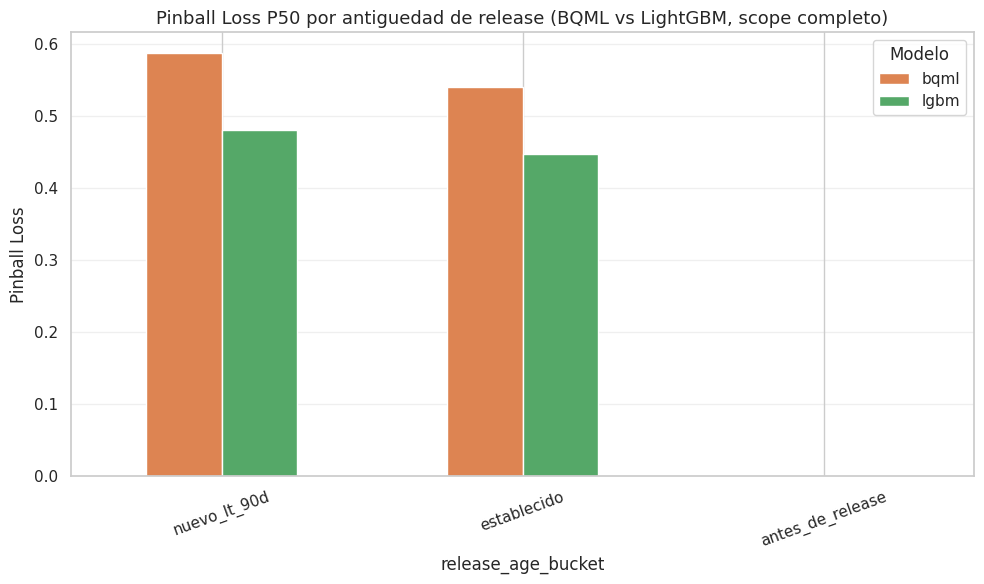

In [16]:
query = f"""
SELECT model, quantile_name, quantile_level, release_age_bucket, in_arima_sample, n_obs, avg_pinball_loss
FROM `{PROJECT}.{DATASET}.cv_metrics_by_release_age`
WHERE quantile_name = 'p50'
ORDER BY release_age_bucket, model
"""
df_age = client.query(query).to_dataframe()
print('n_obs por bucket (scope completo bqml+lgbm, confirma si hay suficiente muestra de productos nuevos):')
display(df_age[df_age['model'].isin(['bqml', 'lgbm'])].groupby('release_age_bucket')['n_obs'].sum())

age_order = [b for b in ['nuevo_lt_90d', 'establecido', 'antes_de_release', 'sin_release_date'] if b in df_age['release_age_bucket'].unique()]
pivot_age_fair, pivot_age_full = fair_and_full(df_age, 'release_age_bucket', age_order)

print('\n=== Comparacion justa (32 series arima_sample, 3 modelos) ===')
display(pivot_age_fair)
print('\n=== BQML vs LightGBM, scope completo (~3,000 series lgbm_sample) ===')
display(pivot_age_full)

pivot_age_full.plot(kind='bar', figsize=(10, 6), color=['#DD8452', '#55A868'])
plt.title('Pinball Loss P50 por antiguedad de release (BQML vs LightGBM, scope completo)', fontsize=13)
plt.ylabel('Pinball Loss')
plt.xticks(rotation=20)
plt.legend(title='Modelo')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.3 Semanas con eventos especiales

Fuente: `cv_metrics_by_event`. `navidad` = 25-dic (Walmart cierra, caso extremo del EDA); `evento` = cualquier otro evento de calendario (`event_name_1`/`event_name_2`); `sin_evento` = resto de los dias.

n_obs por bucket (scope completo bqml+lgbm):


event_bucket
evento         90018
sin_evento    750066
Name: n_obs, dtype: Int64


=== Comparacion justa (32 series arima_sample, 3 modelos) ===


model,arima,bqml,lgbm
event_bucket,,,
evento,1.226698,1.119715,0.846837
sin_evento,1.329608,1.153599,0.877105



=== BQML vs LightGBM, scope completo (~3,000 series lgbm_sample) ===


model,bqml,lgbm
event_bucket,,
evento,0.439547,0.361396
sin_evento,0.460844,0.381201


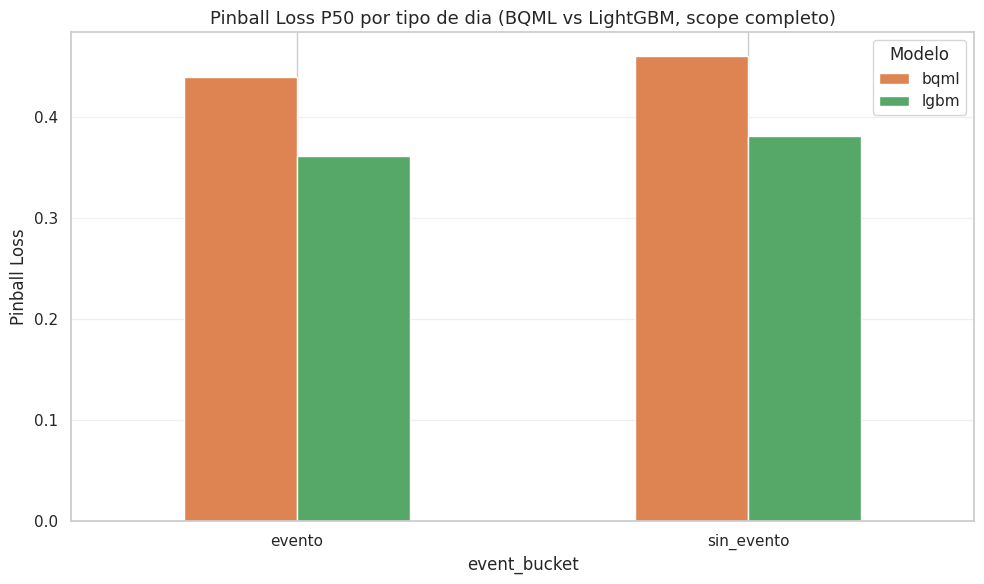

In [17]:
query = f"""
SELECT model, quantile_name, quantile_level, event_bucket, in_arima_sample, n_obs, avg_pinball_loss
FROM `{PROJECT}.{DATASET}.cv_metrics_by_event`
WHERE quantile_name = 'p50'
ORDER BY event_bucket, model
"""
df_event = client.query(query).to_dataframe()
print('n_obs por bucket (scope completo bqml+lgbm):')
display(df_event[df_event['model'].isin(['bqml', 'lgbm'])].groupby('event_bucket')['n_obs'].sum())

event_order = [b for b in ['navidad', 'evento', 'sin_evento'] if b in df_event['event_bucket'].unique()]
pivot_event_fair, pivot_event_full = fair_and_full(df_event, 'event_bucket', event_order)

print('\n=== Comparacion justa (32 series arima_sample, 3 modelos) ===')
display(pivot_event_fair)
print('\n=== BQML vs LightGBM, scope completo (~3,000 series lgbm_sample) ===')
display(pivot_event_full)

pivot_event_full.plot(kind='bar', figsize=(10, 6), color=['#DD8452', '#55A868'])
plt.title('Pinball Loss P50 por tipo de dia (BQML vs LightGBM, scope completo)', fontsize=13)
plt.ylabel('Pinball Loss')
plt.xticks(rotation=0)
plt.legend(title='Modelo')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Convergencia de ARIMA por fold

Insumo adicional para "productos nuevos sin historia": la convergencia de ARIMA clasico cae fuerte en los folds tempranos (ver `phase-summaries/05-walk-forward-cv.md`), consistente con series que aun no acumulan suficiente historia en 2011-2012.

convergio,False,True,pct_converged
fold_id,,,
1,11,21,65.625
2,7,25,78.125
3,8,24,75.0
4,2,30,93.75
5,2,30,93.75


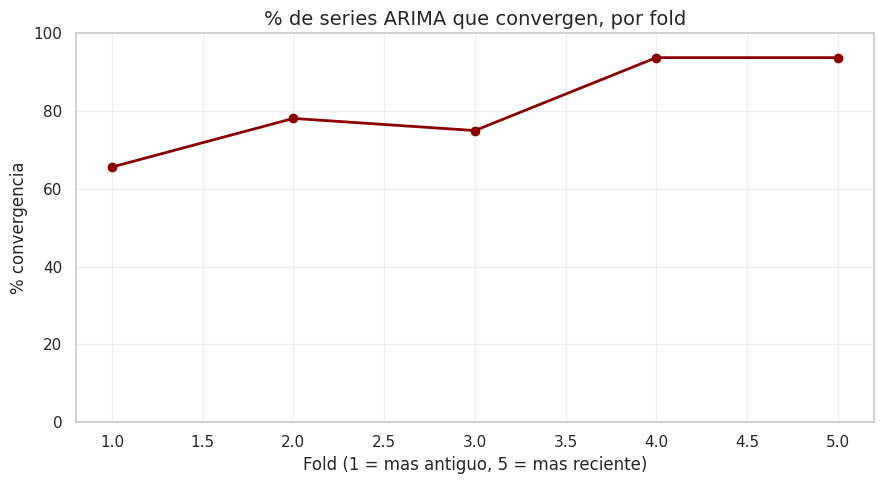

In [18]:
query = f"""
SELECT fold_id, convergio, COUNT(*) AS n_series
FROM `{PROJECT}.{DATASET}.arima_metadata_cv`
GROUP BY fold_id, convergio
ORDER BY fold_id, convergio
"""
df_conv = client.query(query).to_dataframe()
pivot_conv = df_conv.pivot(index='fold_id', columns='convergio', values='n_series').fillna(0)
pivot_conv['pct_converged'] = 100 * pivot_conv.get(True, 0) / pivot_conv.sum(axis=1)
display(pivot_conv)

plt.figure(figsize=(9, 5))
plt.plot(pivot_conv.index, pivot_conv['pct_converged'], marker='o', linewidth=2, color='darkred')
plt.title('% de series ARIMA que convergen, por fold', fontsize=14)
plt.xlabel('Fold (1 = mas antiguo, 5 = mas reciente)')
plt.ylabel('% convergencia')
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Conclusiones

**Comparativa general (Seccion 1, reconfirma Fase 5):** LightGBM Cuantil gana en los 5 percentiles, en ambos alcances. BQML supera a ARIMA en el cuerpo de la distribucion (P25-P75) pero pierde en las colas (P05/P95) -- coherente con que `ARIMA_PLUS` deriva sus intervalos asumiendo normalidad, mientras LightGBM optimiza cada percentil de forma independiente.

**Por categoria de producto (Seccion 2):** LightGBM gana en las 3 categorias (FOODS/HOBBIES/HOUSEHOLD), en ambos alcances -- sin cambios de ranking respecto a la comparativa general. FOODS muestra el error absoluto mas alto en los 3 modelos; probablemente refleja el mayor volumen de venta promedio de esa categoria, no necesariamente que sea "mas dificil" de predecir -- la Pinball Loss implementada aqui no esta escalada (a diferencia de la *Weighted Scaled* Pinball Loss oficial de M5 mencionada en `INSTRUCCIONES.md`), asi que comparar magnitudes absolutas entre categorias/segmentos de distinta escala de venta no es directamente valido. Es una limitacion metodologica real, no un defecto de los modelos.

**Series con alta tasa de ceros (Seccion 3.1):** LightGBM gana en los 4 buckets en ambos alcances (unica excepcion: BQML pierde contra ARIMA en `rapido` dentro del alcance justo, probablemente ruido de muestra pequena). La hipotesis inicial -- que la ventaja de LightGBM se amplia en `muy_lento` -- **no se confirma**: la ventaja relativa de LightGBM sobre BQML es uniforme (~16-19%) en los 4 buckets, sin tendencia clara. El error absoluto cae monotonamente de `rapido` a `muy_lento` en los 3 modelos, consistente con el mismo efecto de escala que en la Seccion 2.

**Productos nuevos (Seccion 3.2 y 4):** en el alcance completo (~3,000 series, el representativo), `nuevo_lt_90d` SI tiene mayor Pinball Loss que `establecido` para BQML (+9%) y LightGBM (+8%) -- confirma que los productos recien lanzados son mas dificiles de predecir. El efecto es moderado y **no se amplifica para LightGBM** frente a BQML (la ventaja relativa de LightGBM es casi identica en ambos buckets). En el alcance justo (32 series) el patron se invierte, probablemente por tamano de muestra insuficiente de productos nuevos dentro de esas 32 series -- otro recordatorio de por que el split de dos alcances es indispensable. La caida de convergencia de ARIMA en folds tempranos (Seccion 4: 66% -> 78% -> 75% -> 94% -> 94%) mide un fenomeno relacionado pero distinto (ventana de entrenamiento corta al inicio del dataset completo, no la antiguedad de un producto individual).

**Eventos especiales (Seccion 3.3) -- hallazgo de diseno real:** ninguna de las 5 ventanas VAL del walk-forward CV cae en diciembre (los 5 folds caen entre enero y abril, ver `phase-summaries/05-walk-forward-cv.md`), asi que **Navidad -- el caso extremo de cierre de tienda documentado en el EDA y modelado explicitamente como feature (`is_christmas`) -- nunca se valida en este esquema de CV**. El bucket `navidad` no tiene ninguna observacion (`n_obs = NA`). Ademas, contraintuitivamente, los dias con evento (no-navidad, ej. SuperBowl/Valentine/Easter) muestran Pinball Loss *menor* que los dias sin evento, en los 3 modelos y ambos alcances -- posible explicacion: los eventos capturados en el rango ene-abr tienen efectos moderados y algo predecibles frente a la variabilidad general del resto del ano.

**Narrativa final del proyecto:** ARIMA establece el piso estadistico, BQML escala eso a produccion pero mantiene las limitaciones de distribucion normal en las colas, LightGBM Cuantil supera a ambos de forma consistente en todos los segmentos analizados (percentil, categoria, tasa de ceros, antiguedad de release). La ventaja de LightGBM es notablemente estable (~15-20%) en vez de concentrarse en los casos "dificiles" esperados -- es una historia mas matizada y honesta que la version simplificada ("LightGBM brilla especialmente en demanda intermitente/productos nuevos"), y vale la pena presentarla asi en la Fase 10: LightGBM gana de forma consistente y pareja, no solo en los extremos.

**Limitacion metodologica a documentar en Fase 10:** esta comparacion responde bien "¿que modelo es mejor en cada segmento?" pero no "¿que segmento es intrinsecamente mas dificil de predecir?", porque la Pinball Loss aqui no esta escalada por el nivel de venta de la serie. Y el walk-forward CV de Fase 5, al espaciar folds uniformemente sin garantizar cobertura estacional completa, nunca prueba el caso Navidad -- la afirmacion "el modelo maneja bien los casos extremos como Navidad" no esta respaldada por este CV especifico, aunque si por el feature engineering de Fase 3.